In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

In [9]:
# Load Excel and parse Date

excel_path = "brain_scans_10yrs.xlsx"
sheet_name = "Monthly"

df = pd.read_excel(excel_path, sheet_name=sheet_name, parse_dates=["Date"])
df.columns = [c.strip() for c in df.columns]


In [17]:
# Keep only needed columns and sort by date
ts = df[["Date", "Total Brain Scans"]].copy().sort_values("Date")

In [19]:
# Set Date as index directly
ts = ts.set_index("Date")

In [31]:
# Define target
y = ts["Total Brain Scans"]

In [33]:
# Quick check
print(ts.head())
print(ts.tail())

            Total Brain Scans
Date                         
2015-04-01           52259.91
2015-05-01           51566.92
2015-06-01           55079.48
2015-07-01           57190.19
2015-08-01           53249.14
            Total Brain Scans
Date                         
2024-11-01           93167.48
2024-12-01           86465.05
2025-01-01           91479.97
2025-02-01           86480.92
2025-03-01           82672.12


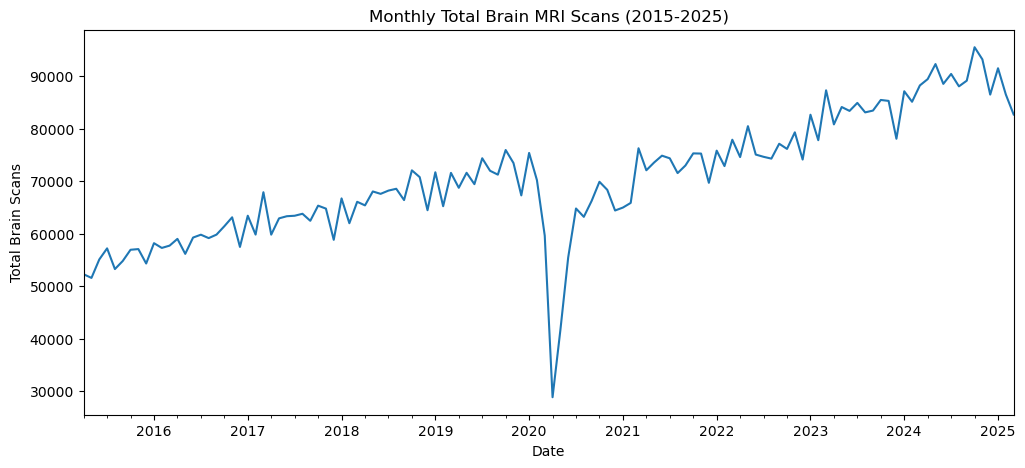

In [70]:
# Plot the total brain scans over time
y.plot(figsize=(12,5), title="Monthly Total Brain MRI Scans (2015-2025)")
plt.xlabel("Date")
plt.ylabel("Total Brain Scans")
plt.show()


In [35]:
# =========================
# 2) Train/Test split & Seasonal Naive baseline
# =========================
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

H = 12  # forecast horizon

y_train = y.iloc[:-H]
y_test  = y.iloc[-H:]

# Seasonal Naive: same month last year
y_hat_sn = y_train.shift(12).iloc[-H:]
y_hat_sn.index = y_test.index  # align with test set

rmse_sn = root_mean_squared_error(y_test, y_hat_sn)
mape_sn = mean_absolute_percentage_error(y_test, y_hat_sn) * 100

print(f"Baseline (Seasonal Naive) -> RMSE: {rmse_sn:,.0f} | MAPE: {mape_sn:.2f}%")


Baseline (Seasonal Naive) -> RMSE: 12,972 | MAPE: 13.83%


# Holt-Winters (Exponential Smoothing)

In [41]:
# =========================
# 3) Holt-Winters (Exponential Smoothing)
# =========================
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

# Suppress ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

# Ensure monthly frequency
y_train = y_train.asfreq("MS")
y_test = y_test.asfreq("MS")

# Fit Holt-Winters with additive trend and seasonality
hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit()

# Forecast for test horizon
hw_forecast = hw_model.forecast(H)
hw_forecast.index = y_test.index  # align with test set

# Calculate RMSE & MAPE
rmse_hw = root_mean_squared_error(y_test, hw_forecast)
mape_hw = mean_absolute_percentage_error(y_test, hw_forecast) * 100

print(f"Holt-Winters -> RMSE: {rmse_hw:,.0f} | MAPE: {mape_hw:.2f}%")


Holt-Winters -> RMSE: 3,866 | MAPE: 3.11%


# ARIMA (non-seasonal)

In [49]:
# =========================
# 4) ARIMA (non-seasonal)
# =========================

arima_model = ARIMA(y_train, order=(1,1,1)).fit()
arima_forecast = arima_model.forecast(steps=H)
arima_forecast.index = y_test.index

rmse_arima = root_mean_squared_error(y_test, arima_forecast)
mape_arima = mean_absolute_percentage_error(y_test, arima_forecast) * 100

print(f"ARIMA(1,1,1) -> RMSE: {rmse_arima:,.0f} | MAPE: {mape_arima:.2f}%")


ARIMA(1,1,1) -> RMSE: 3,934 | MAPE: 3.41%


# SARIMA (seasonal ARIMA via auto_arima)

In [53]:
# =========================
# 5) SARIMA (seasonal ARIMA via auto_arima)
# =========================
import pmdarima as pm

sarima_auto = pm.auto_arima(
    y_train,
    seasonal=True, m=12,
    stepwise=True, suppress_warnings=True, error_action="ignore",
    max_p=3, max_q=3, max_P=2, max_Q=2
)

sarima_forecast = pd.Series(sarima_auto.predict(n_periods=H), index=y_test.index)

rmse_sarima = root_mean_squared_error(y_test, sarima_forecast)
mape_sarima = mean_absolute_percentage_error(y_test, sarima_forecast) * 100

print(f"SARIMA -> RMSE: {rmse_sarima:,.0f} | MAPE: {mape_sarima:.2f}%")


SARIMA -> RMSE: 3,804 | MAPE: 3.33%


# Prophet

In [56]:
# =========================
# 6) Prophet
# =========================
from prophet import Prophet

prophet_train = y_train.reset_index().rename(columns={"Date":"ds","Total Brain Scans":"y"})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="additive")
m.fit(prophet_train)

future = pd.DataFrame({"ds": y_test.index})
prophet_pred = m.predict(future)
prophet_forecast = pd.Series(prophet_pred["yhat"].values, index=y_test.index)

rmse_prophet = root_mean_squared_error(y_test, prophet_forecast)
mape_prophet = mean_absolute_percentage_error(y_test, prophet_forecast) * 100

print(f"Prophet -> RMSE: {rmse_prophet:,.0f} | MAPE: {mape_prophet:.2f}%")


20:57:58 - cmdstanpy - INFO - Chain [1] start processing
20:58:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> RMSE: 5,631 | MAPE: 5.27%


# Compare all models

In [59]:
# =========================
# 7) Compare all models
# =========================
scores = pd.DataFrame({
    "RMSE": [rmse_sn, rmse_hw, rmse_arima, rmse_sarima, rmse_prophet],
    "MAPE": [mape_sn, mape_hw, mape_arima, mape_sarima, mape_prophet]
}, index=["SeasonalNaive","HoltWinters","ARIMA","SARIMA","Prophet"]).sort_values("MAPE")

print(scores)
best = scores.index[0]
print("\nBest model by MAPE:", best)


                       RMSE       MAPE
HoltWinters     3866.385746   3.112697
SARIMA          3803.582792   3.330580
ARIMA           3933.640500   3.412234
Prophet         5631.315165   5.265283
SeasonalNaive  12971.901233  13.829894

Best model by MAPE: HoltWinters


# Final fit on all data & 60-month forecast

In [64]:
# Fit the best model
if best == "HoltWinters":
    final_model = ExponentialSmoothing(
        y.asfreq("MS"), trend="add", seasonal="add", seasonal_periods=12, initialization_method="estimated"
    ).fit()
    y_future = final_model.forecast(H_final)
    y_future.index = idx_future

elif best == "ARIMA":
    final_model = ARIMA(y, order=(1,1,1)).fit()
    y_future = final_model.forecast(H_final)
    y_future.index = idx_future

elif best == "SARIMA":
    final_model = pm.auto_arima(
        y, seasonal=True, m=12, stepwise=True, suppress_warnings=True, error_action="ignore"
    )
    y_future = pd.Series(final_model.predict(n_periods=H_final), index=idx_future)

elif best == "Prophet":
    prophet_all = y.reset_index().rename(columns={"Date":"ds","Total Brain Scans":"y"})
    final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="additive")
    final_model.fit(prophet_all)
    future_all = pd.DataFrame({"ds": idx_future})
    y_future = pd.Series(final_model.predict(future_all)["yhat"].values, index=idx_future)

else:  # fallback Seasonal Naive
    y_future = y.shift(12).reindex(idx_future)

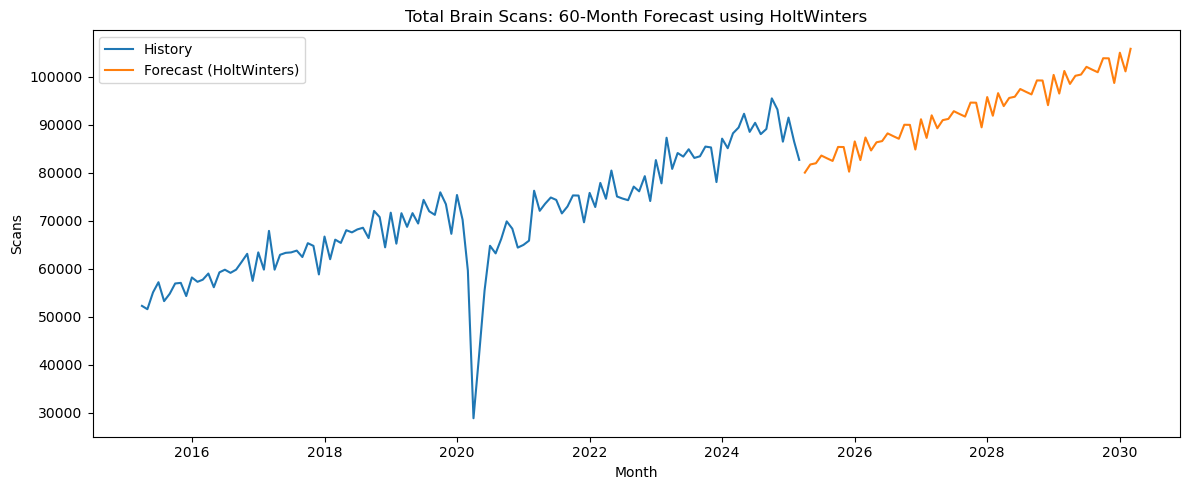

Saved -> brain_scans_60month_forecast.csv


In [66]:
# =========================
# 9) Plot & save forecast
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y.index, y.values, label="History")
plt.plot(y_future.index, y_future.values, label=f"Forecast ({best})")
plt.title(f"Total Brain Scans: 60-Month Forecast using {best}")
plt.xlabel("Month")
plt.ylabel("Scans")
plt.legend()
plt.tight_layout()
plt.show()

# Save forecast to CSV
forecast_df = pd.DataFrame({"History": y, "Forecast": y_future})
forecast_df.to_csv("brain_scans_60month_forecast.csv", index=True)
print("Saved -> brain_scans_60month_forecast.csv")

In [68]:
# =========================
# 10) Next 12 months table
# =========================

# Select the first 12 months from the 60-month forecast
next_12_months = y_future.head(12)

# Create a nicely formatted DataFrame
forecast_table = pd.DataFrame({
    "Month": next_12_months.index.strftime("%Y-%m"),
    "Forecasted Total Brain Scans": next_12_months.values.astype(int)
})

# Display the table
print(forecast_table)

# Optional: save to CSV for report
forecast_table.to_csv("brain_scans_next12_months.csv", index=False)
print("Saved -> brain_scans_next12_months.csv")

      Month  Forecasted Total Brain Scans
0   2025-04                         80017
1   2025-05                         81714
2   2025-06                         81970
3   2025-07                         83576
4   2025-08                         83001
5   2025-09                         82453
6   2025-10                         85368
7   2025-11                         85347
8   2025-12                         80212
9   2026-01                         86519
10  2026-02                         82633
11  2026-03                         87334
Saved -> brain_scans_next12_months.csv
